# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

y_train_cat = to_categorical(trainy, 10)
y_test_cat = to_categorical(testy, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

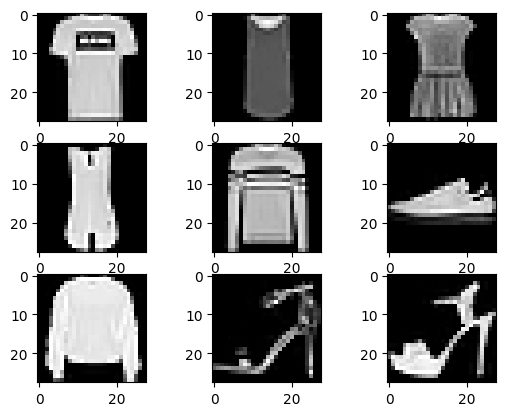

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
model = Sequential([
    # Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10,  activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,226 (864.16 KB)

 Trainable params: 221,226 (864.16 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [ ]:
EPOCH = 5

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    'best_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]



his = model.fit(
    trainX, y_train_cat,
    batch_size=32,
    epochs=EPOCH,
    validation_split=0.2,
    callbacks=callbacks
)


model.evaluate(testX, y_test_cat) # метод evaluate() предназначен для оценки уже обученной модели с использованием данных проверки
                                   #(или тестирования) и соответствующих меток. Возвращает значение потерь и значения показателей для модели.

Epoch 1/5
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7892 - loss: 0.9578
Epoch 1: val_accuracy improved from -inf to 0.87692, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7894 - loss: 0.9553 - val_accuracy: 0.8769 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 2/5
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8894 - loss: 0.3023
Epoch 2: val_accuracy improved from 0.87692 to 0.88925, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8894 - loss: 0.3023 - val_accuracy: 0.8892 - val_loss: 0.3072 - learning_rate: 0.0010
Epoch 3/5
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9022 - loss: 0.2655
Epoch 3: val_accuracy did not improve from 0.88925
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9022 - loss: 0.2655 - val_accuracy: 0.8882 - val_loss: 0.3131 - learning_rate: 0.0010
Epoch 4/5
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9092 - loss: 0.2409
Epoch 4: val_accuracy improved from 0.88925 to 0.89683, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9092 - loss: 0.2409 - val_accuracy: 0.8968 - val_loss: 0.2797 - learning_rate: 0.0010
Epoch 5/5
1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.2115
Epoch 5: val_accuracy improved from 0.89683 to 0.89983, saving model to best_cnn.h5


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9212 - loss: 0.2115 - val_accuracy: 0.8998 - val_loss: 0.2909 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8886 - loss: 0.3037


[0.30003058910369873, 0.8916000127792358]

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

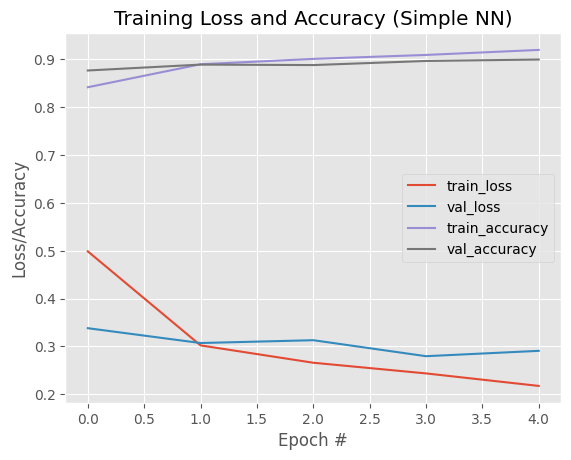

In [ ]:
N = np.arange(0, EPOCH)
plt.style.use("ggplot")
plt.figure()
plt.plot(N, his.history["loss"], label="train_loss")
plt.plot(N, his.history["val_loss"], label="val_loss")
plt.plot(N, his.history["accuracy"], label="train_accuracy")
plt.plot(N, his.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy (Simple NN)")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [ ]:
# Скачиваем архив с набором данных
!curl -L -o clothes_dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/ryanbadai/clothes-dataset


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1405M  100 1405M    0     0  20.1M      0  0:01:09  0:01:09 --:--:-- 21.3M


In [ ]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip clothes_dataset.zip -d new_dataset

In [ ]:
import os
from glob import glob

base_dir = '/content/new_dataset/Clothes_Dataset'

kaggle_classes = ['Polo', 'Jeans', 'Hoodie', 'Kemeja', 'Jaket']

image_paths = []
true_labels = []

for cls in kaggle_classes:
    folder = os.path.join(base_dir, cls)
    files = sorted(glob(os.path.join(folder, '*')))
    if not files:
        continue
    image_paths.append(files[0])
    true_labels.append(cls)

len(image_paths), image_paths

(5,
 ['/content/new_dataset/Clothes_Dataset/Polo/001068a8-86c3-4029-a9d9-1e27015e7e64.jpg',
  '/content/new_dataset/Clothes_Dataset/Jeans/08973288-3d8b-4c07-9f2d-ce1392da54be.jpg',
  '/content/new_dataset/Clothes_Dataset/Hoodie/halfzip_hoodie_awk_1697034196_0d90db76_progressive_thumbnail.jpg',
  '/content/new_dataset/Clothes_Dataset/Kemeja/00e745c9-97d9-429d-8c3f-d3db7a2d2991.jpg',
  '/content/new_dataset/Clothes_Dataset/Jaket/jaket_bomber_reborn__audi_hita_1692870832_39a7fd4b_progressive_thumbnail.jpg'])

In [ ]:
import numpy as np
from PIL import Image

IMG_SIZE = 28

def preprocess_image(path):
    img = Image.open(path).convert('L')      # в оттенки серого
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype('float32')
    # arr = arr / 255.0
    arr = 255.0 - arr

    arr = arr.reshape(IMG_SIZE, IMG_SIZE, 1)
    return arr

X_new = np.stack([preprocess_image(p) for p in image_paths], axis=0)
X_new.shape


(5, 28, 28, 1)

In [ ]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [ ]:
probs = model.predict(X_new)
pred_indices = np.argmax(probs, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


In [ ]:
for path, true_label, pred_idx in zip(image_paths, true_labels, pred_indices):
    print('Файл:', path)
    print('  Kaggle класс (папка):', true_label)
    print('  Предсказание модели (Fashion-MNIST):', class_names[pred_idx])
    print()


Файл: /content/new_dataset/Clothes_Dataset/Polo/001068a8-86c3-4029-a9d9-1e27015e7e64.jpg
  Kaggle класс (папка): Polo
  Предсказание модели (Fashion-MNIST): Bag

Файл: /content/new_dataset/Clothes_Dataset/Jeans/08973288-3d8b-4c07-9f2d-ce1392da54be.jpg
  Kaggle класс (папка): Jeans
  Предсказание модели (Fashion-MNIST): Trouser

Файл: /content/new_dataset/Clothes_Dataset/Hoodie/halfzip_hoodie_awk_1697034196_0d90db76_progressive_thumbnail.jpg
  Kaggle класс (папка): Hoodie
  Предсказание модели (Fashion-MNIST): Coat

Файл: /content/new_dataset/Clothes_Dataset/Kemeja/00e745c9-97d9-429d-8c3f-d3db7a2d2991.jpg
  Kaggle класс (папка): Kemeja
  Предсказание модели (Fashion-MNIST): Shirt

Файл: /content/new_dataset/Clothes_Dataset/Jaket/jaket_bomber_reborn__audi_hita_1692870832_39a7fd4b_progressive_thumbnail.jpg
  Kaggle класс (папка): Jaket
  Предсказание модели (Fashion-MNIST): Bag



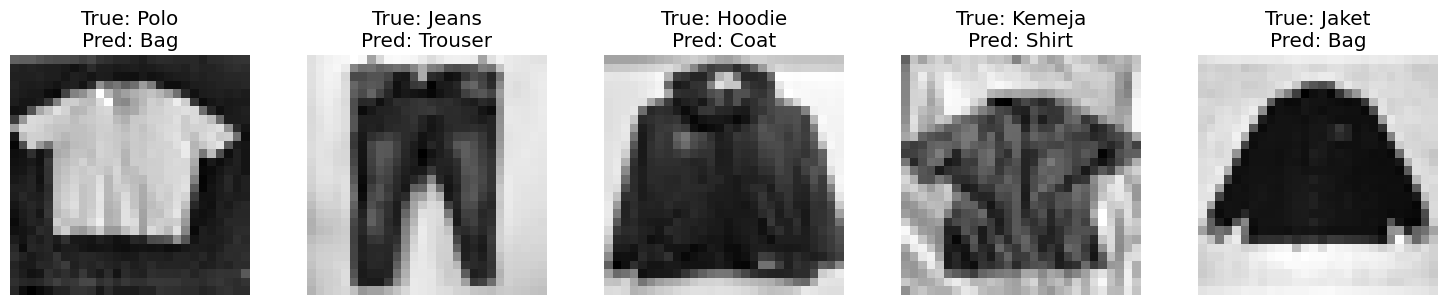

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i, (path, true_label, pred_idx) in enumerate(zip(image_paths, true_labels, pred_indices)):
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    plt.subplot(1, len(image_paths), i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'True: {true_label}\nPred: {class_names[pred_idx]}')

plt.tight_layout()
plt.show()


# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**

In [3]:
# 2.1. Загрузка и распаковка датасета с цветами

!mkdir -p data
!curl -L -o data/flowers_dataset.zip "https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset"
!unzip -q data/flowers_dataset.zip -d data/flowers_dataset




  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0  13.4M      0  0:00:16  0:00:16 --:--:-- 14.7M
flower_photos


In [5]:
# проверим, что внутри архива
!ls data/flowers_dataset/flower_photos

# корень датасета — будем дальше ссылаться на него
DATASET_PATH = "data/flowers_dataset/flower_photos"

daisy  dandelion  roses  sunflowers  tulips


In [6]:
# 2.2. Подготовка генераторов изображений для датасета цветов

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_gen.num_classes
print("Классов в датасете:", num_classes)
print("Словарь классов:", train_gen.class_indices)


Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Классов в датасете: 5
Словарь классов: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}



## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [7]:
# 2.3. Модель глубокой сверточной сети для классификации цветов

from tensorflow.keras import layers, models, regularizers

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.SeparableConv2D(32, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.SeparableConv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.30)(x)

x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.40)(x)
x = layers.Dense(
    128,
    activation='relu',
    kernel_regularizer=regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.40)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

flowers_model = models.Model(inputs, outputs, name="flowers_cnn_custom")
flowers_model.summary()


Model: "flowers_cnn_custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 32)   │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,51

 Total params: 135,941 (531.02 KB)

 Trainable params: 135,045 (527.52 KB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
# 2.4. Компиляция и обучение модели

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

flowers_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "flowers_cnn_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

EPOCHS = 25

history = flowers_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)


Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.4147 - loss: 1.3987
Epoch 1: val_accuracy improved from None to 0.24487, saving model to flowers_cnn_best.keras

Epoch 1: finished saving model to flowers_cnn_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 451ms/step - accuracy: 0.4682 - loss: 1.3060 - val_accuracy: 0.2449 - val_loss: 1.6221 - learning_rate: 0.0010
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5513 - loss: 1.1302
Epoch 2: val_accuracy did not improve from 0.24487
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - accuracy: 0.5594 - loss: 1.1088 - val_accuracy: 0.2449 - val_loss: 1.7099 - learning_rate: 0.0010
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6231 - loss: 1.0028
Epoch 3: val_accuracy did not improve from 0.24487
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.6237 - loss: 1.0167 - val_accuracy: 0.2449 - val_loss: 1.8365 - learning_rate: 0.0010
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7620 - loss: 0.8235
Validation accuracy: 0.762, validation loss: 0.823


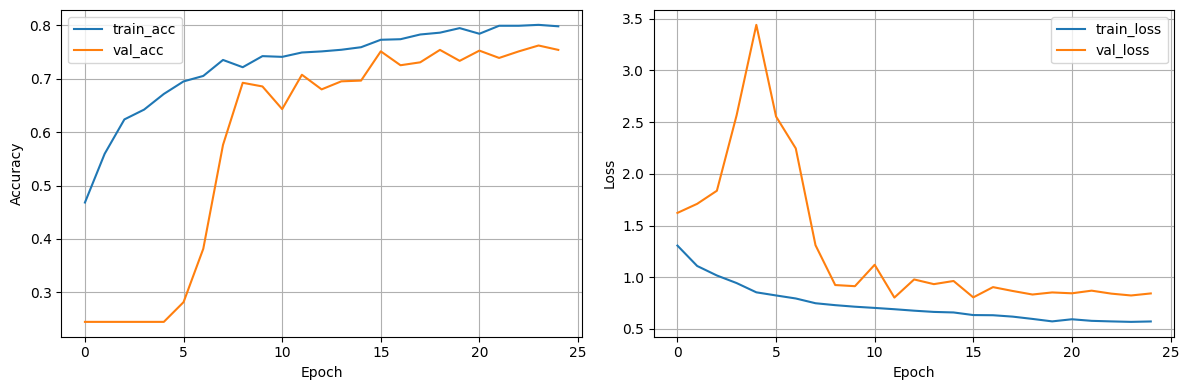

In [9]:
# 2.5. Оценка модели и визуализация истории обучения

import matplotlib.pyplot as plt
import numpy as np

val_loss, val_acc = flowers_model.evaluate(val_gen)
print(f"Validation accuracy: {val_acc:.3f}, validation loss: {val_loss:.3f}")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

VGG_IMG_SIZE = 224
VGG_BATCH_SIZE = 32

vgg_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # вместо rescale
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

vgg_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

vgg_train_gen = vgg_train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(VGG_IMG_SIZE, VGG_IMG_SIZE),
    batch_size=VGG_BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

vgg_val_gen = vgg_val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(VGG_IMG_SIZE, VGG_IMG_SIZE),
    batch_size=VGG_BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

vgg_num_classes = vgg_train_gen.num_classes
print("Классов (VGG):", vgg_num_classes)
print("Словарь классов:", vgg_train_gen.class_indices)


Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Классов (VGG): 5
Словарь классов: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# базовая VGG16 без «головы» ImageNet
vgg_base = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(VGG_IMG_SIZE, VGG_IMG_SIZE, 3),
    pooling='avg'   # GlobalAveragePooling2D внутри
)

# на первом шаге заморозим feature extractor
for layer in vgg_base.layers:
    layer.trainable = False

vgg_x = vgg_base.output
vgg_x = layers.Dense(256, activation='relu')(vgg_x)
vgg_x = layers.Dropout(0.5)(vgg_x)
vgg_output = layers.Dense(vgg_num_classes, activation='softmax')(vgg_x)

vgg_model = models.Model(inputs=vgg_base.input, outputs=vgg_output, name="flowers_vgg16")

vgg_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "flowers_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_checkpoint = ModelCheckpoint(
    "flowers_vgg16_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

vgg_early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

vgg_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

VGG_EPOCHS = 15  # можно увеличить, если GPU тянет

vgg_history = vgg_model.fit(
    vgg_train_gen,
    epochs=VGG_EPOCHS,
    validation_data=vgg_val_gen,
    callbacks=[vgg_checkpoint, vgg_early_stopping, vgg_reduce_lr]
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.2482 - loss: 6.3968
Epoch 1: val_accuracy improved from None to 0.58003, saving model to flowers_vgg16_best.keras

Epoch 1: finished saving model to flowers_vgg16_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 78s 678ms/step - accuracy: 0.3307 - loss: 4.9082 - val_accuracy: 0.5800 - val_loss: 1.6611 - learning_rate: 1.0000e-04
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.4927 - loss: 2.7864
Epoch 2: val_accuracy improved from 0.58003 to 0.70588, saving model to flowers_vgg16_best.keras

Epoch 2: finished saving model to flowers_vgg16_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 517ms/step - accuracy: 0.5322 - loss: 2.4176 - val_accuracy: 0.7059 - val_loss: 1.0869 - learning_rate: 1.0000e-04
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.6043 - loss: 1.8369
Epoch 3: val_accuracy improved from 0.70588 to 0.75376, saving model to flowers_vgg16_best.keras

Epoch 3: finished saving model to flowers

## 2.3. Сохраните полученные модели

In [13]:
# Сохранение обученной VGG16-модели в файл

SAVE_PATH = "flowers_vgg16_final.keras"

vgg_model.save(SAVE_PATH)
print(f"Модель сохранена в файл: {SAVE_PATH}")


Модель сохранена в файл: flowers_vgg16_final.keras


## 2.4. Загрузите обученную модель из прошлой практической работы


In [14]:
# Загрузка обученной модели из прошлой практической работы

from tensorflow.keras.models import load_model

PREV_MODEL_PATH = "classifier.h5"  # <-- укажи здесь реальное имя файла

prev_flowers_model = load_model(PREV_MODEL_PATH)
prev_flowers_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,424,583 (24.51 MB)

 Trainable params: 6,424,581 (24.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [17]:
# 2.X. Сравнение трёх моделей на 15 одинаковых изображениях

import os
import glob
import random
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1) Соберём список всех файлов и выберем 15 случайных разных изображений
all_images = glob.glob(os.path.join(DATASET_PATH, "*", "*.jpg")) \
           + glob.glob(os.path.join(DATASET_PATH, "*", "*.png")) \
           + glob.glob(os.path.join(DATASET_PATH, "*", "*.jpeg"))

random.seed(42)
sample_paths = random.sample(all_images, 15)
print("Выбрано изображений:", len(sample_paths))

# 2) Словарь классов (берём из любого генератора по этому датасету)
class_indices = vgg_train_gen.class_indices  # или train_gen.class_indices, если он у тебя есть
idx_to_class = {v: k for k, v in class_indices.items()}

# 3) Вспомогательная функция: подготовка батча под конкретную модель
def make_batch(paths, target_size, preprocess_fn):
    batch = []
    true_idx = []
    for p in paths:
        # истинный класс = имя родительской папки
        class_name = os.path.basename(os.path.dirname(p))
        true_idx.append(class_indices[class_name])

        img = load_img(p, target_size=target_size)
        arr = img_to_array(img)
        arr = np.expand_dims(arr, axis=0)
        if preprocess_fn is not None:
            arr = preprocess_fn(arr)
        batch.append(arr[0])
    return np.stack(batch), np.array(true_idx)

# 4) Подготовка входов для каждой модели

custom_size = flowers_model.input_shape[1:3]
vgg_size    = vgg_model.input_shape[1:3]

# прошлый модуль: (None, 12288) -> 64x64x3
prev_flat_dim = prev_flowers_model.input_shape[1]  # 12288
prev_side = int((prev_flat_dim / 3) ** 0.5)        # 64
prev_size = (prev_side, prev_side)

def rescale_1_255(x):
    return x / 255.0

# для кастомной модели
X_custom, y_true = make_batch(sample_paths, custom_size, rescale_1_255)

# для прошлой модели: 64x64, затем reshape в (batch, 12288)
X_prev_img, _ = make_batch(sample_paths, prev_size, rescale_1_255)
X_prev = X_prev_img.reshape(X_prev_img.shape[0], -1)

# для VGG16
X_vgg, _ = make_batch(sample_paths, vgg_size, preprocess_input)

# 5) Предсказания трёх моделей

pred_custom = flowers_model.predict(X_custom, verbose=0)
pred_prev   = prev_flowers_model.predict(X_prev, verbose=0)
pred_vgg    = vgg_model.predict(X_vgg, verbose=0)

pred_custom_idx = np.argmax(pred_custom, axis=1)
pred_prev_idx   = np.argmax(pred_prev,   axis=1)
pred_vgg_idx    = np.argmax(pred_vgg,    axis=1)

# 6) Подсчёт "точности" на этих 15 примерах

acc_custom = np.mean(pred_custom_idx == y_true)
acc_prev   = np.mean(pred_prev_idx   == y_true)
acc_vgg    = np.mean(pred_vgg_idx    == y_true)

print(f"Custom CNN accuracy (15 img): {acc_custom:.3f}")
print(f"Prev model accuracy  (15 img): {acc_prev:.3f}")
print(f"VGG16 model accuracy  (15 img): {acc_vgg:.3f}")

# 7) Табличка с предсказаниями

print("\nСравнение предсказаний по каждому изображению:\n")
print("{:<3} {:<25} {:<12} {:<12} {:<12} {:<12}".format(
    "#", "file", "true", "custom", "prev", "vgg16"
))
print("-"*80)

for i, path in enumerate(sample_paths):
    true_name   = idx_to_class[y_true[i]]
    custom_name = idx_to_class[pred_custom_idx[i]]
    prev_name   = idx_to_class[pred_prev_idx[i]]
    vgg_name    = idx_to_class[pred_vgg_idx[i]]

    fname = os.path.basename(path)
    print("{:<3} {:<25} {:<12} {:<12} {:<12} {:<12}".format(
        i+1, fname[:24], true_name, custom_name, prev_name, vgg_name
    ))


Выбрано изображений: 15
Custom CNN accuracy (15 img): 0.800
Prev model accuracy  (15 img): 0.200
VGG16 model accuracy  (15 img): 0.933

Сравнение предсказаний по каждому изображению:

#   file                      true         custom       prev         vgg16       
--------------------------------------------------------------------------------
1   14372713423_61e2daae88.j  daisy        daisy        dandelion    daisy       
2   14025589299_eac64c51af_m  tulips       dandelion    dandelion    tulips      
3   14270573963_f122c40438.j  tulips       tulips       dandelion    tulips      
4   136011860_44ca0b2835_n.j  dandelion    dandelion    daisy        dandelion   
5   14460081668_eda8795693_m  sunflowers   sunflowers   daisy        sunflowers  
6   22255608949_172d7c8d22_m  sunflowers   sunflowers   daisy        sunflowers  
7   9399711558_7cb9547cd3_n.  sunflowers   sunflowers   dandelion    sunflowers  
8   5719416820_3060e3c1f0.jp  tulips       tulips       dandelion    sunflowers

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [18]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [19]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [20]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

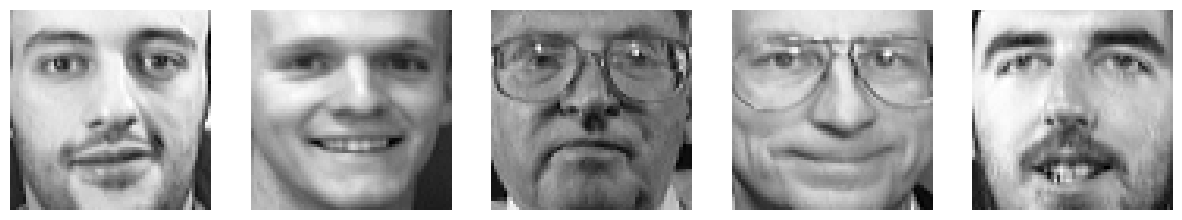

In [21]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [22]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [23]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

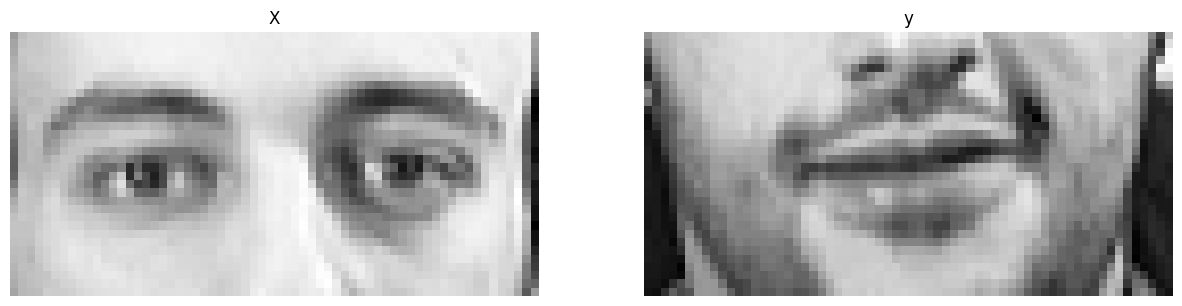

In [24]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [25]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [26]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

faces_model = Sequential([
    # Вход: верхняя половина лица 32x64
    Flatten(input_shape=(32, 64)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(2048, activation='sigmoid')  # 32*64 выходных пикселей
])

faces_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2048)           │       526,336 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,706,752 (6.51 MB)

 Trainable params: 1,706,752 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [27]:
# 3.3. Скомпилируйте сеть

from keras.optimizers import Adam

faces_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',       # регрессия по пикселям
    metrics=['mae']   # будем смотреть среднюю абсолютную ошибку
)


## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [28]:
# 3.4. Обучите нейросеть

from keras.callbacks import EarlyStopping, ReduceLROnPlateau

EPOCHS = 100
BATCH_SIZE = 32

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history_faces = faces_model.fit(
    X_train,          # верхняя половина лица (32x64)
    y_train_n,        # нижняя половина в виде вектора (2048)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0261 - mae: 0.1311 - val_loss: 0.0231 - val_mae: 0.1237 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0214 - mae: 0.1182 - val_loss: 0.0217 - val_mae: 0.1195 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0206 - mae: 0.1157 - val_loss: 0.0215 - val_mae: 0.1190 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0201 - mae: 0.1144 - val_loss: 0.0211 - val_mae: 0.1185 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0198 - mae: 0.1135 - val_loss: 0.0207 - val_mae: 0.1168 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0194 - mae: 0.1120 - val_loss: 0.0202 - val_mae: 0.1150 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0188 - mae: 0.1101 - val_loss: 0.0189 - val_mae: 0.1110 - learning_rate: 0.0010
Epoch 8/100
8/8 ━━━━

## 3.5. Сделайте предсказания на тестовых данных

In [29]:
# 3.5. Сделайте предсказания на тестовых данных

preds = faces_model.predict(X_test)  # форма: (кол-во тестовых, 2048)
print(preds.shape)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step
(80, 2048)


## 3.6. Посчитайте метрику качества на тестовых данных

In [30]:
# 3.6. Посчитайте метрику качества на тестовых данных

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_n, preds)
print(f"Mean Absolute Error (MAE) на тесте: {mae:.4f}")


Mean Absolute Error (MAE) на тесте: 0.0862


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [31]:
# 3.7. Преобразуйте предсказанные векторы в двумерное изображение

pred_test = preds.reshape(preds.shape[0], 32, 64)
print("Форма pred_test:", pred_test.shape)


Форма pred_test: (80, 32, 64)


Отрисуйте все предсказания.

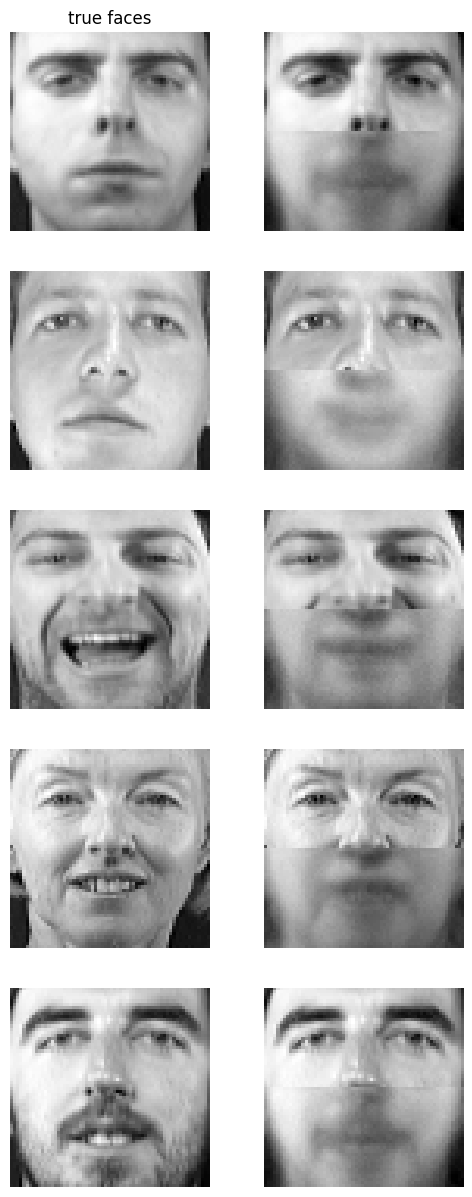

In [32]:
# Пример кода:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


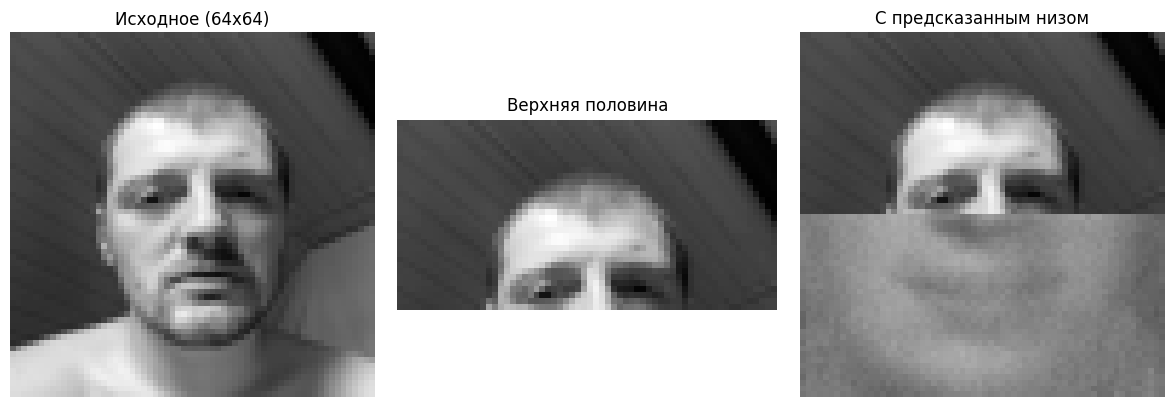

In [49]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Путь к загруженному фото в Colab
img_path = "/content/face.jpg"  # <-- поменяй на свой

# 2. Загрузка и приведение к формату Olivetti: 64x64, grayscale, [0..1]
IMGSIZE = 64

img = Image.open(img_path).convert("L")          # grayscale
img = img.resize((IMGSIZE, IMGSIZE))             # 64x64
img_arr = np.array(img).astype("float32") / 255. # нормализация как в датасете

# 3. Вырезаем верхнюю половину и приводим к форме, как X_train
upper_half = img_arr[:32, :]                     # (32, 64)
upper_half_input = upper_half.reshape(1, 32, 64) # батч из 1 картинки

# 4. Предсказываем нижнюю половину
pred_vec = faces_model.predict(upper_half_input)[0]   # (2048,)
pred_lower = pred_vec.reshape(32, 64)                 # (32, 64)

# 5. Склеиваем верх и предсказанный низ в одно 64x64 изображение
completed_face = np.vstack([upper_half, pred_lower])  # (64, 64)

# 6. Отрисовываем: исходник (подготовленный), верх, реконструкция
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Исходное (64x64)")
plt.imshow(img_arr, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Верхняя половина")
plt.imshow(upper_half, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("С предсказанным низом")
plt.imshow(completed_face, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
